# Experiments Guide

## 0. Colab Setup

In [ ]:
!git clone -b dev-explainable-clustering-for-prototypes https://github.com/luigiaceto/explainable-models-for-speech-analysis.git
%cd explainable-models-for-speech-analysis
%pip install -r requirements-colab.txt

## 1. Project Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.audio_features import pooled_feature_dim
from src.utils.naming import (
    blackbox_penultimate_feature_dir_name,
    blackbox_run_dir_name,
    model_name_to_slug,
    pooled_feature_dir_name,
    prototype_clustering_run_dir_name
)

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / "crema_d"
AUDIO_DIR = RAW_DIR / "AudioWAV"

# (model_name, dimension_of_the_original_vectors_generated_by_the_model)
FEATURE_EXTRACTOR = ("microsoft/wavlm-large", 1024)

FEATURE_EXTRACTOR_NAME, ENCODER_EMBEDDING_DIM = FEATURE_EXTRACTOR
FEATURE_EXTRACTOR_ID = model_name_to_slug(FEATURE_EXTRACTOR_NAME)
FEATURE_POOLING = "mean_std"
FEATURE_DIM = pooled_feature_dim(ENCODER_EMBEDDING_DIM, FEATURE_POOLING)

FEATURE_DIR = DATA_DIR / "features" / pooled_feature_dir_name(FEATURE_EXTRACTOR_NAME, FEATURE_POOLING)
BLACK_BOX_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / blackbox_run_dir_name(FEATURE_EXTRACTOR_NAME)
BLACK_BOX_REPORT_DIR = PROJECT_ROOT / "reports" / blackbox_run_dir_name(FEATURE_EXTRACTOR_NAME)
BLACK_BOX_EMBEDDING_DIR = DATA_DIR / "features" / blackbox_penultimate_feature_dir_name(FEATURE_EXTRACTOR_NAME)

FEATURE_EXTRACTION_BATCH_SIZE = 8
FEATURE_EXTRACTION_NUM_WORKERS = 0
RANDOM_STATE = 42

PROTOTYPE_CLUSTERING_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / prototype_clustering_run_dir_name(FEATURE_EXTRACTOR_NAME)
PROTOTYPE_CLUSTERING_REPORT_DIR = PROJECT_ROOT / "reports" / prototype_clustering_run_dir_name(FEATURE_EXTRACTOR_NAME)

PROJECT_ROOT

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis')

## 2. Download CREMA-D

In [2]:
from src.preprocessing.download_crema_d import download_crema_d

metadata = download_crema_d(
    output_dir=RAW_DIR,
    overwrite=False
)

metadata.head(n=10)

,file_name,actor_id,sentence_code,sentence,emotion_code,emotion,label,intensity_code,intensity,audio_path
0,1001_DFA_ANG_XX.wav,1001,DFA,Don't forget a jacket,ANG,anger,0,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
1,1001_DFA_DIS_XX.wav,1001,DFA,Don't forget a jacket,DIS,disgust,1,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
2,1001_DFA_FEA_XX.wav,1001,DFA,Don't forget a jacket,FEA,fear,2,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
3,1001_DFA_HAP_XX.wav,1001,DFA,Don't forget a jacket,HAP,happy,3,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
4,1001_DFA_NEU_XX.wav,1001,DFA,Don't forget a jacket,NEU,neutral,4,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
5,1001_DFA_SAD_XX.wav,1001,DFA,Don't forget a jacket,SAD,sad,5,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
6,1001_IEO_ANG_HI.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,HI,high,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
7,1001_IEO_ANG_LO.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,LO,low,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
8,1001_IEO_ANG_MD.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,MD,medium,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
9,1001_IEO_DIS_HI.wav,1001,IEO,It's eleven o'clock,DIS,disgust,1,HI,high,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...


## 3. Dataset Statistics

In [3]:
from src.data.crema_d import print_dataset_statistics

print_dataset_statistics(metadata)

Total samples: 7442
Actors: 91
Sentence prompts: 12

Samples per emotion:
emotion  sample_count  percentage
  anger          1271   17.078742
disgust          1271   17.078742
   fear          1271   17.078742
  happy          1271   17.078742
neutral          1087   14.606289
    sad          1271   17.078742


## 4. Extract Frozen Audio Encoder Features

In [4]:
from src.preprocessing.extract_audio_features import extract_audio_features

feature_paths = extract_audio_features(
    metadata_csv=RAW_DIR / "metadata.csv",
    audio_dir=AUDIO_DIR,
    output_dir=FEATURE_DIR,
    model_name=FEATURE_EXTRACTOR_NAME,
    expected_encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    batch_size=FEATURE_EXTRACTION_BATCH_SIZE,
    num_workers=FEATURE_EXTRACTION_NUM_WORKERS,
    overwrite=False
)

feature_paths

{'features': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/wavlm_large_mean_std/features.npy'),
 'metadata': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/wavlm_large_mean_std/metadata.csv'),
 'config': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/wavlm_large_mean_std/feature_config.json')}

## 5. Train the Black-Box Classifier

In [ ]:
from src.training.train_blackbox import TrainingConfig, train_blackbox

SPLIT_STRATEGY = "sample_stratified"
#SPLIT_STRATEGY = "speaker_independent" # each split has different voice actors

training_config = TrainingConfig(
    input_dim=FEATURE_DIM,
    feature_extractor_name=FEATURE_EXTRACTOR_NAME,
    encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    hidden_dims=(256, 128),
    batch_size=64,
    epochs=100,
    dropout=0.25,
    learning_rate=2e-4,
    weight_decay=5e-4,
    split_strategy=SPLIT_STRATEGY,
    speaker_column="actor_id",
    early_stopping_patience=15,
    #lr_scheduler=None, # by default the scheduler is active. Need to set it explicitly to None if we wanna turn it off
    scheduler_patience=6,
    random_state=RANDOM_STATE
)

training_results = train_blackbox(
    feature_dir=FEATURE_DIR,
    output_dir=BLACK_BOX_CHECKPOINT_DIR,
    config=training_config
)

## 6. Evaluate the Black-Box Classifier

In [5]:
from src.evaluation.evaluate_blackbox import evaluate_blackbox, print_classification_metrics

test_metrics = evaluate_blackbox(
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    feature_dir=FEATURE_DIR,
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split="test",
    output_dir=BLACK_BOX_REPORT_DIR
)

print_classification_metrics(test_metrics)

Accuracy:    0.7708
Macro F1:    0.7717
Weighted F1: 0.7698

Classification report:
emotion precision recall f1_score  support
  anger    0.8513 0.8691   0.8601      191
disgust    0.7697 0.6649   0.7135      191
   fear    0.7380 0.7263   0.7321      190
  happy    0.7590 0.7749   0.7668      191
neutral    0.8229 0.8834   0.8521      163
    sad    0.6900 0.7225   0.7059      191


/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/src/data/crema_d.py:175: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.labels = torch.as_tensor(


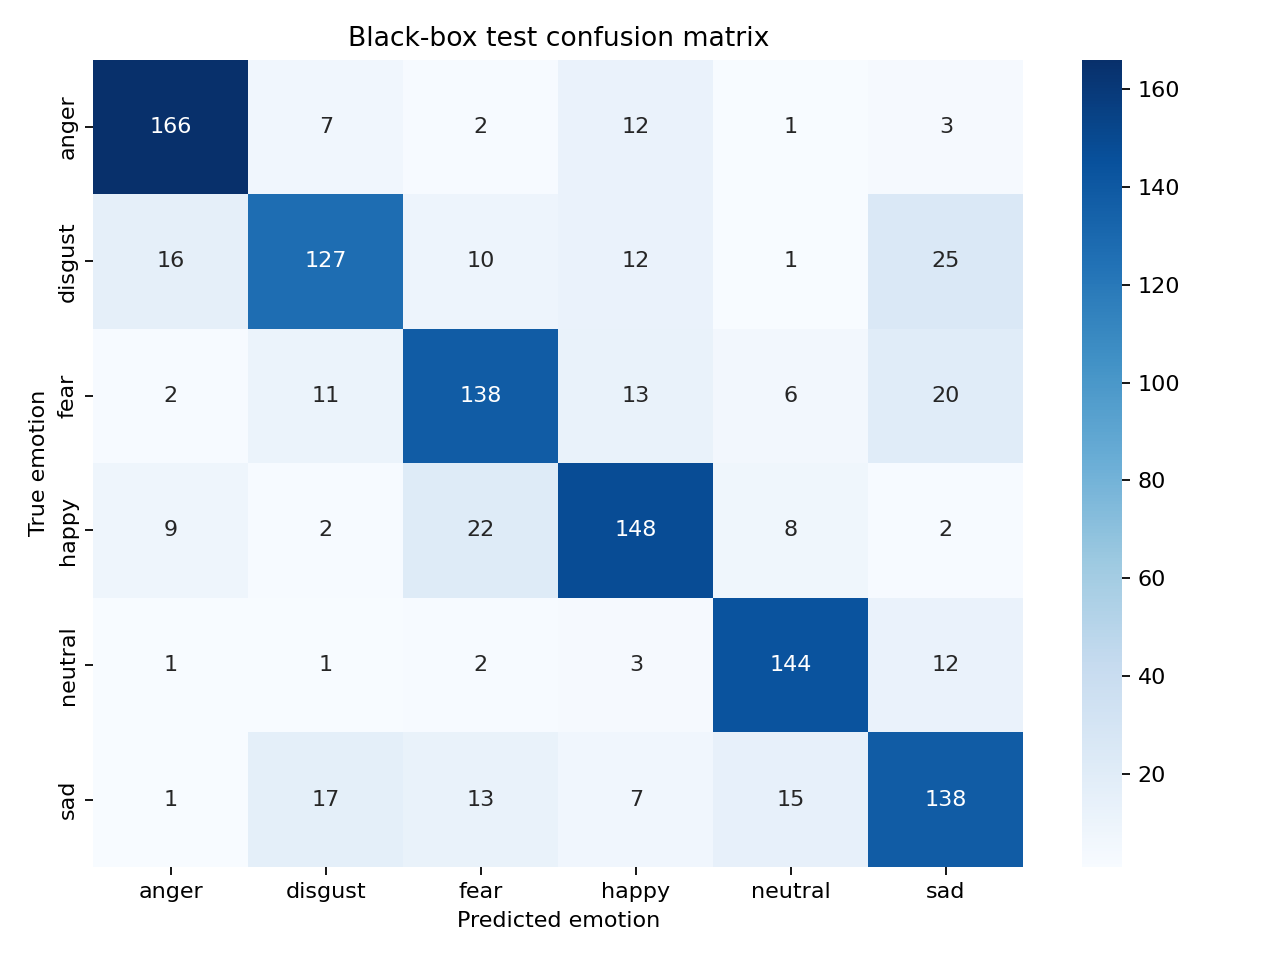

In [6]:
from IPython.display import Image, display

confusion_matrix_path = BLACK_BOX_REPORT_DIR / "test_confusion_matrix.png"
if confusion_matrix_path.exists():
    display(Image(filename=str(confusion_matrix_path)))

## 7. Visualize Embedding Spaces

Project the pooled audio encoder features and the trained black-box penultimate representations to two PCA dimensions.


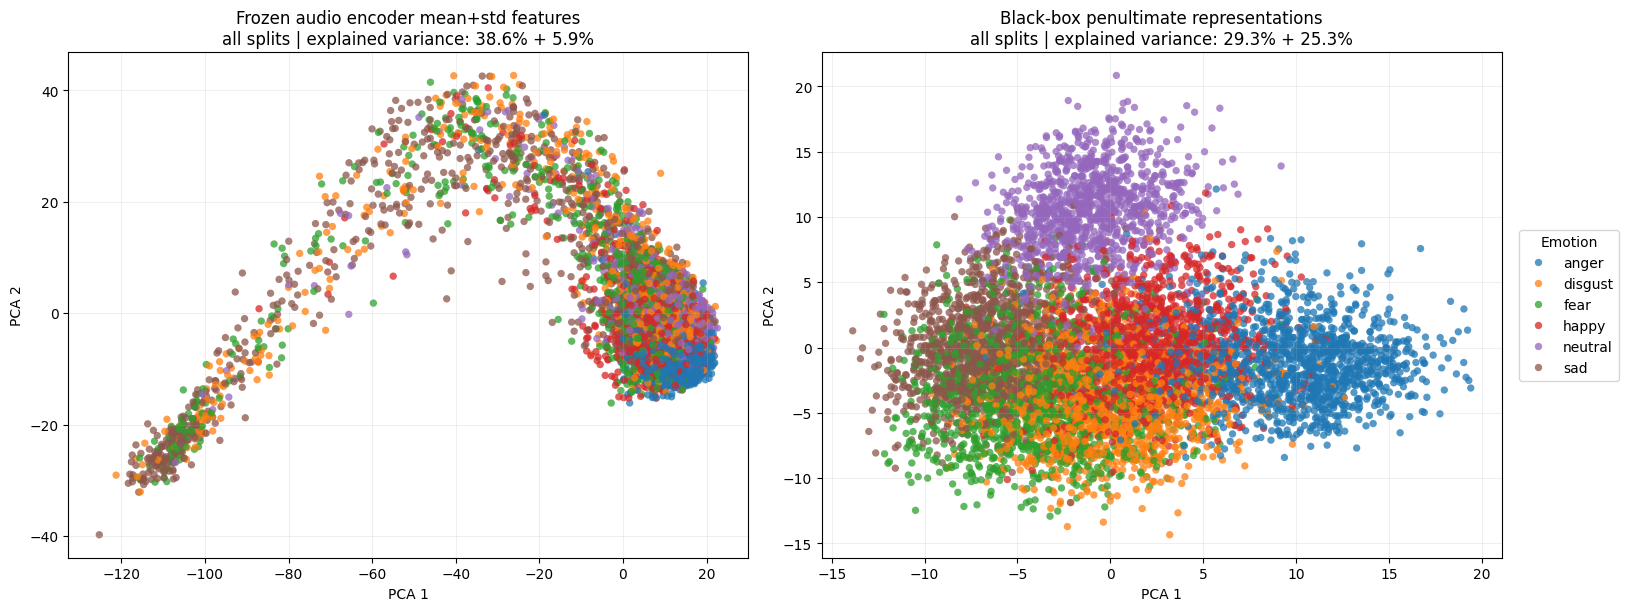

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/reports/blackbox_wavlm_large/all_embedding_pca.png')

In [ ]:
from src.utils.visualize import plot_blackbox_embedding_pca

split_to_visualize = "all"

embedding_pca_result = plot_blackbox_embedding_pca(
    feature_dir=FEATURE_DIR,
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split=split_to_visualize,
    output_path=BLACK_BOX_REPORT_DIR / f"{split_to_visualize}_embedding_pca.png",
    random_state=RANDOM_STATE
)

embedding_pca_result["output_path"]

## 8. Extract Black-Box Penultimate Embeddings

Extract the 128-dimensional representation before the final black-box classification layer and save its L2-normalized version.

In [8]:
from src.preprocessing.extract_blackbox_embeddings import extract_blackbox_penultimate_embeddings

blackbox_embedding_paths = extract_blackbox_penultimate_embeddings(
    feature_dir=FEATURE_DIR,
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    output_dir=BLACK_BOX_EMBEDDING_DIR,
    batch_size=256,
    overwrite=False
)

blackbox_embedding_paths

{'features': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_wavlm_large_penultimate_l2/features.npy'),
 'metadata': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_wavlm_large_penultimate_l2/metadata.csv'),
 'config': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_wavlm_large_penultimate_l2/embedding_config.json')}

## 9. Prototype Clustering Grid Search

Fit K-means on the training split only, with K clusters per emotion. Each centroid is mapped to the nearest real training sample of the same emotion, and these real prototypes are used for classification. Select K and top-N on the validation split.

In [9]:
from src.training.train_prototype_clustering import (
    PrototypeClusteringTrainingConfig,
    train_prototype_clustering
)

prototype_training_config = PrototypeClusteringTrainingConfig(
    embedding_dim=128,
    cluster_counts=(1, 2, 3, 4, 5, 8, 10),
    top_ns=(1, 3, 5, 7, 9),
    monitor_metric="macro_f1",
    random_state=RANDOM_STATE
)

prototype_training_results = train_prototype_clustering(
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    output_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    config=prototype_training_config
)

K=01, top-N=01 | val acc 0.7401, macro F1 0.7415, weighted F1 0.7387
K=01, top-N=03 | val acc 0.7401, macro F1 0.7415, weighted F1 0.7387
K=01, top-N=05 | val acc 0.7401, macro F1 0.7415, weighted F1 0.7387
K=02, top-N=01 | val acc 0.7285, macro F1 0.7315, weighted F1 0.7283
K=02, top-N=03 | val acc 0.7204, macro F1 0.7186, weighted F1 0.7152
K=02, top-N=05 | val acc 0.7366, macro F1 0.7351, weighted F1 0.7319
K=02, top-N=07 | val acc 0.7339, macro F1 0.7327, weighted F1 0.7294
K=02, top-N=09 | val acc 0.7339, macro F1 0.7327, weighted F1 0.7294
K=03, top-N=01 | val acc 0.7303, macro F1 0.7318, weighted F1 0.7286
K=03, top-N=03 | val acc 0.7312, macro F1 0.7314, weighted F1 0.7285
K=03, top-N=05 | val acc 0.7428, macro F1 0.7425, weighted F1 0.7396
K=03, top-N=07 | val acc 0.7419, macro F1 0.7407, weighted F1 0.7380
K=03, top-N=09 | val acc 0.7455, macro F1 0.7446, weighted F1 0.7419
K=04, top-N=01 | val acc 0.7177, macro F1 0.7196, weighted F1 0.7162
K=04, top-N=03 | val acc 0.7240, m

## 10. Evaluate Prototype Clustering Classifier

In [10]:
from src.evaluation.evaluate_prototype_clustering import (
    evaluate_prototype_clustering,
    print_prototype_clustering_metrics
)

prototype_test_metrics = evaluate_prototype_clustering(
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    split="test",
    output_dir=PROTOTYPE_CLUSTERING_REPORT_DIR
)

print_prototype_clustering_metrics(prototype_test_metrics)

Accuracy:    0.7440
Macro F1:    0.7432
Weighted F1: 0.7410


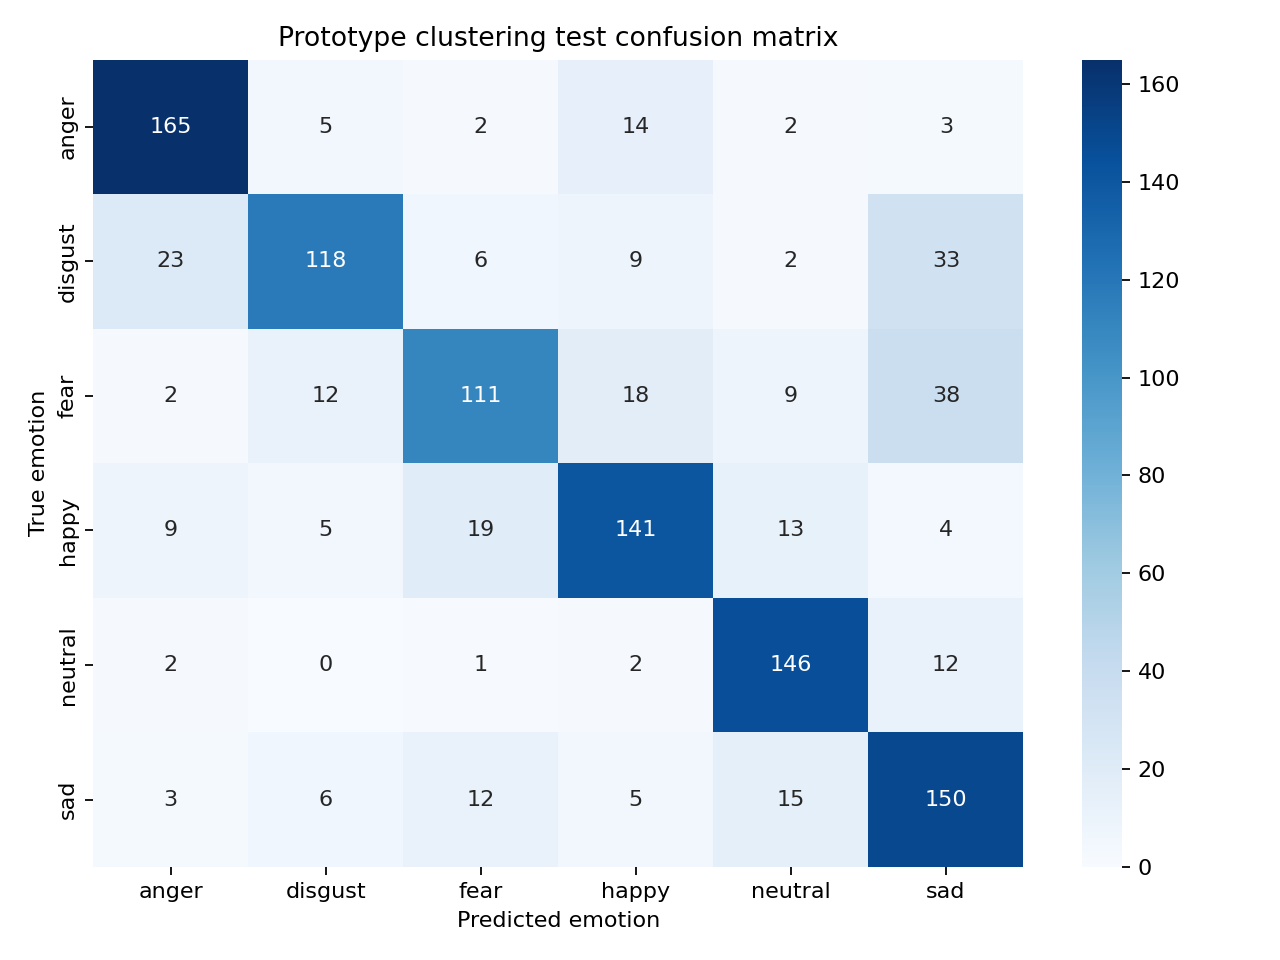

In [11]:
from IPython.display import Image, display

prototype_confusion_matrix_path = PROTOTYPE_CLUSTERING_REPORT_DIR / "test_confusion_matrix.png"
if prototype_confusion_matrix_path.exists():
    display(Image(filename=str(prototype_confusion_matrix_path)))

## 11. Visualize Prototype Embedding Space

Project the saved 128-dimensional L2-normalized black-box embeddings to two PCA dimensions and highlight the prototypes of each emotion.

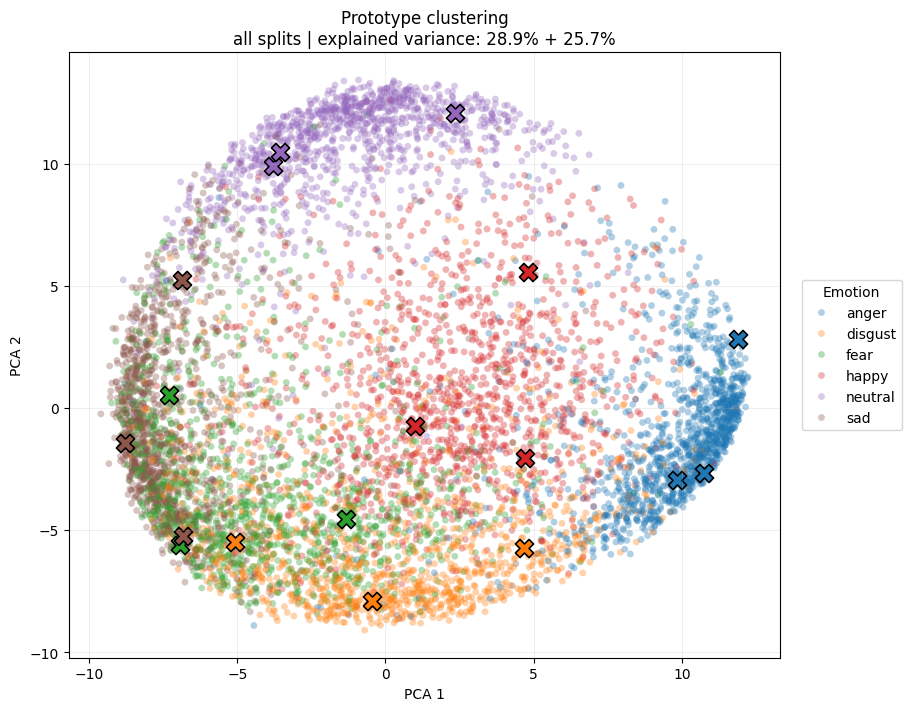

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/reports/prototype_clustering_wavlm_large/all_prototype_embedding_pca.png')

In [2]:
from src.utils.visualize import plot_prototype_embedding_pca

prototype_pca_result = plot_prototype_embedding_pca(
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    split="all",
    output_path=PROTOTYPE_CLUSTERING_REPORT_DIR / "all_prototype_embedding_pca.png",
    random_state=RANDOM_STATE
)

prototype_pca_result["output_path"]

## 12. Explanation By Example - Inspect Prototype Neighbors of a Test Sample

Inspect one sample using the saved 128D embeddings and saved real prototypes. This does not reprocess the WAV file.

In [3]:
import pandas as pd
from src.explainability.prototype_neighbors import (
    explain_sample_by_filename,
    print_prototype_explanation
)

# Set a CREMA-D file name here, or leave it as None to use the first test sample.
SAMPLE_TO_EXPLAIN = "1014_IWL_DIS_XX.wav"

prototype_explanation = explain_sample_by_filename(
    embedding_metadata=pd.read_csv(BLACK_BOX_EMBEDDING_DIR / "metadata.csv"),
    sample_to_explain=SAMPLE_TO_EXPLAIN,
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR
)

print_prototype_explanation(prototype_explanation)

Sample:    1014_IWL_DIS_XX.wav
True:      disgust
Predicted: disgust

Class scores:
    anger: 0.0000
  disgust: 2.4172
     fear: 2.1812
    happy: 0.6217
  neutral: 0.0000
      sad: 1.6731

Top-9 prototypes:
  #01 disgust | sim 0.9405 | 1010_DFA_DIS_XX.wav
  #02     sad | sim 0.9154 | 1058_ITH_SAD_XX.wav
  #03    fear | sim 0.8393 | 1014_ITS_FEA_XX.wav
  #04 disgust | sim 0.8183 | 1039_IWL_DIS_XX.wav
  #05     sad | sim 0.7577 | 1030_IWW_SAD_XX.wav
  #06    fear | sim 0.6993 | 1012_IEO_FEA_LO.wav
  #07 disgust | sim 0.6584 | 1059_WSI_DIS_XX.wav
  #08    fear | sim 0.6426 | 1076_TAI_FEA_XX.wav
  #09   happy | sim 0.6217 | 1047_ITS_HAP_XX.wav


In [4]:
from IPython.display import Audio, display, Markdown

display(Markdown(f"### Sample: `{SAMPLE_TO_EXPLAIN}`"))
display(Audio(filename=str(AUDIO_DIR / SAMPLE_TO_EXPLAIN)))

display(Markdown("### Top prototypes"))
for prototype in prototype_explanation["top_prototypes"]:
    prototype_file = prototype.get("prototype_file_name")
    if prototype_file is None:
        continue

    display(Markdown(
        f"**#{prototype['rank']} | {prototype['prototype_emotion']} | "
        f"similarity: {prototype['similarity']:.4f}**  \n"
        f"`{prototype_file}`"
    ))
    display(Audio(filename=str(AUDIO_DIR / prototype_file)))

### Sample: `1014_IWL_DIS_XX.wav`

### Top prototypes

**#1 | disgust | similarity: 0.9405**  
`1010_DFA_DIS_XX.wav`

**#2 | sad | similarity: 0.9154**  
`1058_ITH_SAD_XX.wav`

**#3 | fear | similarity: 0.8393**  
`1014_ITS_FEA_XX.wav`

...

**#5 | sad | similarity: 0.7577**  
`1030_IWW_SAD_XX.wav`

**#6 | fear | similarity: 0.6993**  
`1012_IEO_FEA_LO.wav`

**#7 | disgust | similarity: 0.6584**  
`1059_WSI_DIS_XX.wav`

**#8 | fear | similarity: 0.6426**  
`1076_TAI_FEA_XX.wav`

**#9 | happy | similarity: 0.6217**  
`1047_ITS_HAP_XX.wav`